In [2]:
import torch
import matplotlib.pyplot as plt

In [37]:
def h00(t):
    return 2 * t**3 - 3 * t**2 + 1

def h10(t):
    return t**3 - 2 * t**2 + t

def h01(t):
    return -2 * t**3 + 3 * t**2

def h11(t):
    return t**3 - t**2

def hermite(p0, p1, m0, m1, t):
    return h00(t) * p0 + h10(t) * m0 + h01(t) * p1 + h11(t) * m1

In [47]:
ts = torch.linspace(0, 1, 100)

p0 = 0.0
m0 = 1.0
p1 = 0.0
m1 = -1.0

ys = hermite(p0, p1, m0, m1, ts)

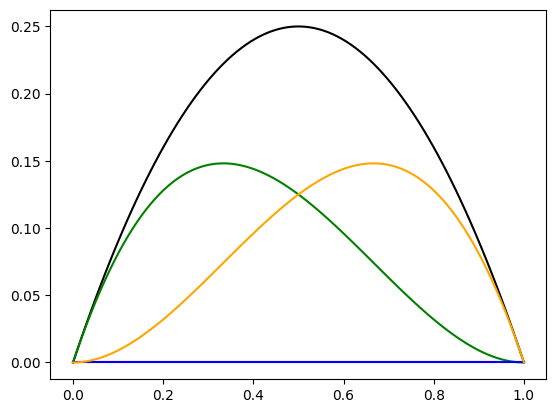

In [54]:
plt.plot(ts, ys, color='black')
plt.plot(ts, h00(ts)*p0, color='red')
plt.plot(ts, h10(ts)*m0,  color='green')
plt.plot(ts, h01(ts)*p1, color='blue')
plt.plot(ts, h11(ts)*m1, color='orange')


In [15]:
def slope_to_angle(m):
    return torch.atan(torch.tensor(m)) * 180 / torch.pi

In [16]:
slope_to_angle(1.0)

tensor(45.)

In [87]:
ts= torch.linspace(0, 1, 100)

In [96]:
xsplit = 0.5

# coeffs = (p0, p1, m0, m1)

p0, p1, m0, m1 = 0.0, 0.0, 1.0, -1.0

coeffs = [
    (0.0, 0.25, 1./2,  0),
    (0.25, 0.0, 0, -1.0/2),
]

mask = (ts <= xsplit).to(torch.float32)
ts1 = ts / xsplit
ts2 = (ts - xsplit) / (1 - xsplit)

In [97]:
ys1 = hermite(*coeffs[0], ts1)
ys2 = hermite(*coeffs[1], ts2)

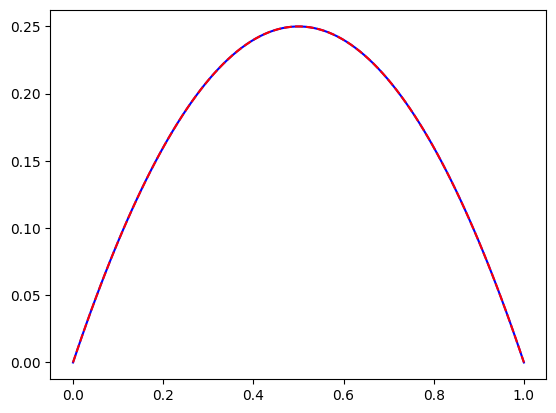

In [110]:
ys = mask * ys1 + (1 - mask) * ys2
ys_ = hermite(p0, p1, m0, m1, ts)

plt.plot(ts, ys, color='blue')
plt.plot(ts, ys_, color='red', ls="--", alpha=1)
# plt.plot(ts, h00(ts)*p0, color='red')
# plt.plot(ts, h10(ts)*m0,  color='green')
# plt.plot(ts, h01(ts)*p1, color='blue')
# plt.plot(ts, h11(ts)*m1, color='orange')

In [262]:
import numpy as np
coeffs = np.polynomial.hermite.hermfit(xs, ys, 1)

In [263]:
coeffs

array([1.1649832e+00, 6.5731447e-09], dtype=float32)

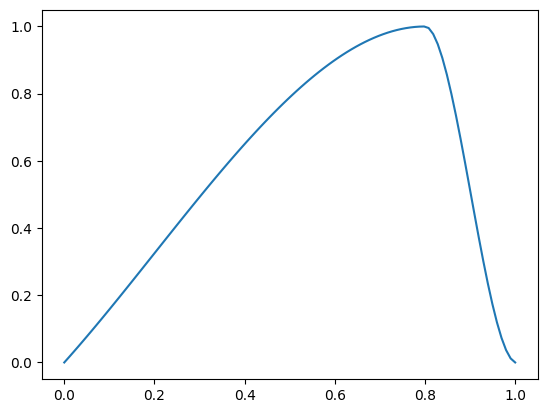

In [272]:
xk = 0.8
eps = 0.0001

# coeff = (p0, p1, m0, m1)
coeffs = [
    (0.0, 1.0, 1.2, 0.0),
    (1.0, 0.0, 0.0, -0.1)
]

# Generate a set of parameter values in the range [0, 1]
ts = torch.linspace(0, 1, 100)

# Perform connected Hermite spline interpolation
mask = (ts <= xk).float()

t_spline1 = ts / xk
t_spline2 = (ts - xk) / (1 - xk + eps)

spline1_values = hermite(*coeffs[0], t_spline1)
spline2_values = hermite(*coeffs[1], t_spline2)

result = mask * spline1_values + (1 - mask) * spline2_values

# Visualize the result or use it for further computations
plt.plot(ts, result)


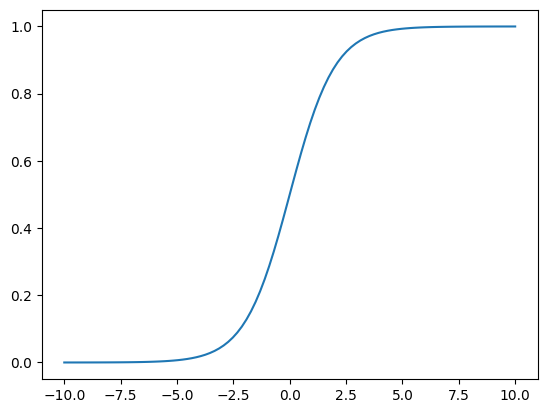

In [164]:
import torch.nn.functional as F
ts = torch.linspace(-10, 10, 100)
labels = F.sigmoid(ts)
plt.plot(ts, labels)

In [202]:
from tqdm import tqdm
from torch import optim, nn
import torch.nn.functional as F

class SimpleNet(nn.Module):
    def __init__(self, length=100):
        super(SimpleNet, self).__init__()
        self.fc = nn.Linear(length, 5)
        
        self.p_mid = 0.1
        self.m0 = 0.1
        self.m_mid = 0.1
        self.m1 = 0.1
        self.x_mid = 0.1
        self.ts = torch.linspace(0, 1, length)
        
    def forward(self, x):
        p_mid, m0, m_mid, m1, x_mid_ = F.tanh(self.fc(x))
        
        self.p_mid = p_mid
        self.m0 = m0
        self.m_mid = m_mid
        self.m1 = m1
        self.x_mid = x_mid_.sigmoid()
        
        mask = (self.ts <= self.x_mid).float()
        ts1 = self.ts / self.x_mid
        ts2 = (self.ts - self.x_mid) / (1 - self.x_mid)
        ys1 = self._hermite(0, self.p_mid, self.m0, self.m_mid, ts1)
        ys2 = self._hermite(self.p_mid, 0, self.m_mid, self.m1, ts2)
        return mask * ys1 + (1 - mask) * ys2
    
    @staticmethod
    def _hermite(p0, p1, m0, m1, ts):
        t3 = ts**3
        t2 = ts**2
        h00 = 2 * t3 - 3 * t2 + 1
        h10 = t3 - 2 * t2 + ts
        h01 = -2 * t3 + 3 * t2
        h11 = t3 - t2
        return h00 * p0 + h10 * m0 + h01 * p1 + h11 * m1
    
    def get_coeffs(self):
        return 0, self.p_mid.detach(), self.m0.detach(), 0, self.m_mid.detach(), self.m1.detach(), self.x_mid.sigmoid().detach()
    
model =  SimpleNet()
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = F.mse_loss
# Dummy dataset (replace this with your actual dataset)
# Assume input size is 10 and the number of classes is 2
ts = torch.linspace(0, 1, 100)
labels = -ts**2 + ts
# data is labels + noise with torch
data = labels.clone() + torch.randn_like(labels) * 0.001

# Training loop
num_epochs = 10000

for epoch in tqdm(range(num_epochs)):
    # Forward pass
    outputs = model(data)
    loss = criterion(outputs, labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

100%|██████████| 10000/10000 [00:02<00:00, 3358.87it/s]


(0, tensor(0.2545), tensor(0.4908), 0, tensor(-0.0025), tensor(-0.3940), tensor(0.6280))


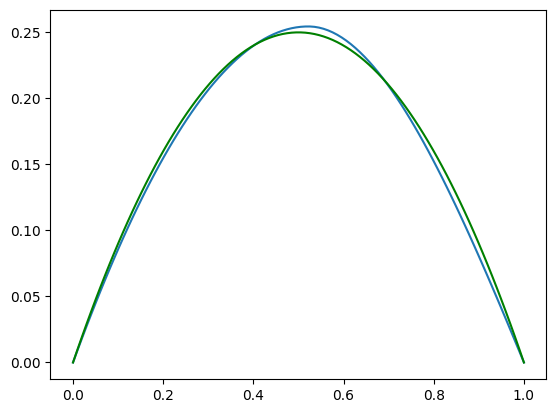

In [203]:
with torch.no_grad():
    
    result = model(data)
    coeffs = model.get_coeffs()
    print(coeffs)
    
    # Visualize the result or use it for further computations
    plt.plot(ts.detach().numpy(), result.detach().numpy())      
    # plt.plot(ts.detach().numpy(), data.detach().numpy(), color='black')
    plt.plot(ts.detach().numpy(), labels.detach().numpy(), color='green')

In [207]:
ts

tensor([0.0000, 0.0101, 0.0202, 0.0303, 0.0404, 0.0505, 0.0606, 0.0707, 0.0808,
        0.0909, 0.1010, 0.1111, 0.1212, 0.1313, 0.1414, 0.1515, 0.1616, 0.1717,
        0.1818, 0.1919, 0.2020, 0.2121, 0.2222, 0.2323, 0.2424, 0.2525, 0.2626,
        0.2727, 0.2828, 0.2929, 0.3030, 0.3131, 0.3232, 0.3333, 0.3434, 0.3535,
        0.3636, 0.3737, 0.3838, 0.3939, 0.4040, 0.4141, 0.4242, 0.4343, 0.4444,
        0.4545, 0.4646, 0.4747, 0.4848, 0.4949, 0.5051, 0.5152, 0.5253, 0.5354,
        0.5455, 0.5556, 0.5657, 0.5758, 0.5859, 0.5960, 0.6061, 0.6162, 0.6263,
        0.6364, 0.6465, 0.6566, 0.6667, 0.6768, 0.6869, 0.6970, 0.7071, 0.7172,
        0.7273, 0.7374, 0.7475, 0.7576, 0.7677, 0.7778, 0.7879, 0.7980, 0.8081,
        0.8182, 0.8283, 0.8384, 0.8485, 0.8586, 0.8687, 0.8788, 0.8889, 0.8990,
        0.9091, 0.9192, 0.9293, 0.9394, 0.9495, 0.9596, 0.9697, 0.9798, 0.9899,
        1.0000])

In [206]:
torch.arange(0, 90) / (90 - 1)

tensor([0.0000, 0.0112, 0.0225, 0.0337, 0.0449, 0.0562, 0.0674, 0.0787, 0.0899,
        0.1011, 0.1124, 0.1236, 0.1348, 0.1461, 0.1573, 0.1685, 0.1798, 0.1910,
        0.2022, 0.2135, 0.2247, 0.2360, 0.2472, 0.2584, 0.2697, 0.2809, 0.2921,
        0.3034, 0.3146, 0.3258, 0.3371, 0.3483, 0.3596, 0.3708, 0.3820, 0.3933,
        0.4045, 0.4157, 0.4270, 0.4382, 0.4494, 0.4607, 0.4719, 0.4831, 0.4944,
        0.5056, 0.5169, 0.5281, 0.5393, 0.5506, 0.5618, 0.5730, 0.5843, 0.5955,
        0.6067, 0.6180, 0.6292, 0.6404, 0.6517, 0.6629, 0.6742, 0.6854, 0.6966,
        0.7079, 0.7191, 0.7303, 0.7416, 0.7528, 0.7640, 0.7753, 0.7865, 0.7978,
        0.8090, 0.8202, 0.8315, 0.8427, 0.8539, 0.8652, 0.8764, 0.8876, 0.8989,
        0.9101, 0.9213, 0.9326, 0.9438, 0.9551, 0.9663, 0.9775, 0.9888, 1.0000])